### Cancer Identification: 
#### Predict whether a cancer tumour is benign (non-cancerous) or malignant (cancerous) based on various cell nucleus features.

The goal of this project is to develop a machine learning model using the Breast Cancer dataset to accurately classify 
whether a tumour is benign or malignant based on cell nucleus features extracted from the visual characteristics of the cancer and the average values of these characteristics. 
The model aims to assist early cancer detection and improve diagnostic efficiency. 

    
https://www.kaggle.com/datasets/erdemtaha/cancer-data

#### Import Libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Setting to make numbers easier to read on display
pd.options.display.float_format = '{:20.2f}'.format

# Show all columns on output
pd.set_option('display.max_columns', 999)

#### Import data

In [2]:
# check the current working directory
import os
print(os.getcwd())

C:\Users\udeni\Desktop\CancerIdentification


In [3]:
# Change directory
os.chdir(r'C:\Users\Udeni\Desktop\CancerIdentification')

# Verify
print("Current Working Directory:", os.getcwd())

Current Working Directory: C:\Users\Udeni\Desktop\CancerIdentification


In [4]:
df = pd.read_csv("Cancer_Data.csv")

#### Data exploration

In [5]:
# First, check the attributes of the dataset
df.shape

(569, 33)

In [6]:
# Check the first five rows of the data in the dataset
df.head(5)


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.00,0.12,0.28,0.30,0.15,0.24,0.08,1.09,0.91,8.59,153.40,0.01,0.05,0.05,0.02,0.03,0.01,25.38,17.33,184.60,2019.00,0.16,0.67,0.71,0.27,0.46,0.12,NaN
1,842517,M,20.57,17.77,132.90,1326.00,0.08,0.08,0.09,0.07,0.18,0.06,0.54,0.73,3.40,74.08,0.01,0.01,0.02,0.01,0.01,0.00,24.99,23.41,158.80,1956.00,0.12,0.19,0.24,0.19,0.28,0.09,NaN
2,84300903,M,19.69,21.25,130.00,1203.00,0.11,0.16,0.20,0.13,0.21,0.06,0.75,0.79,4.58,94.03,0.01,0.04,0.04,0.02,0.02,0.00,23.57,25.53,152.50,1709.00,0.14,0.42,0.45,0.24,0.36,0.09,NaN
3,84348301,M,11.42,20.38,77.58,386.10,0.14,0.28,0.24,0.11,0.26,0.10,0.50,1.16,3.44,27.23,0.01,0.07,0.06,0.02,0.06,0.01,14.91,26.50,98.87,567.70,0.21,0.87,0.69,0.26,0.66,0.17,NaN
4,84358402,M,20.29,14.34,135.10,1297.00,0.10,0.13,0.20,0.10,0.18,0.06,0.76,0.78,5.44,94.44,0.01,0.02,0.06,0.02,0.02,0.01,22.54,16.67,152.20,1575.00,0.14,0.20,0.40,0.16,0.24,0.08,NaN


In [7]:
# Check the data type for each variable.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [8]:
# Check the statistics of the variables
df.describe()

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
count,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,0.00
mean,30371831.43,14.13,19.29,91.97,654.89,0.10,0.10,0.09,0.05,0.18,0.06,0.41,1.22,2.87,40.34,0.01,0.03,0.03,0.01,0.02,0.00,16.27,25.68,107.26,880.58,0.13,0.25,0.27,0.11,0.29,0.08,NaN
std,125020585.61,3.52,4.30,24.30,351.91,0.01,0.05,0.08,0.04,0.03,0.01,0.28,0.55,2.02,45.49,0.00,0.02,0.03,0.01,0.01,0.00,4.83,6.15,33.60,569.36,0.02,0.16,0.21,0.07,0.06,0.02,NaN
min,8670.00,6.98,9.71,43.79,143.50,0.05,0.02,0.00,0.00,0.11,0.05,0.11,0.36,0.76,6.80,0.00,0.00,0.00,0.00,0.01,0.00,7.93,12.02,50.41,185.20,0.07,0.03,0.00,0.00,0.16,0.06,NaN
25%,869218.00,11.70,16.17,75.17,420.30,0.09,0.06,0.03,0.02,0.16,0.06,0.23,0.83,1.61,17.85,0.01,0.01,0.02,0.01,0.02,0.00,13.01,21.08,84.11,515.30,0.12,0.15,0.11,0.06,0.25,0.07,NaN
50%,906024.00,13.37,18.84,86.24,551.10,0.10,0.09,0.06,0.03,0.18,0.06,0.32,1.11,2.29,24.53,0.01,0.02,0.03,0.01,0.02,0.00,14.97,25.41,97.66,686.50,0.13,0.21,0.23,0.10,0.28,0.08,NaN
75%,8813129.00,15.78,21.80,104.10,782.70,0.11,0.13,0.13,0.07,0.20,0.07,0.48,1.47,3.36,45.19,0.01,0.03,0.04,0.01,0.02,0.00,18.79,29.72,125.40,1084.00,0.15,0.34,0.38,0.16,0.32,0.09,NaN
max,911320502.00,28.11,39.28,188.50,2501.00,0.16,0.35,0.43,0.20,0.30,0.10,2.87,4.88,21.98,542.20,0.03,0.14,0.40,0.05,0.08,0.03,36.04,49.54,251.20,4254.00,0.22,1.06,1.25,0.29,0.66,0.21,NaN


In [9]:
# Check the total missing values in each column
df.isna().sum()

id                           0
diagnosis                    0
radius_mean                  0
texture_mean                 0
perimeter_mean               0
area_mean                    0
smoothness_mean              0
compactness_mean             0
concavity_mean               0
concave points_mean          0
symmetry_mean                0
fractal_dimension_mean       0
radius_se                    0
texture_se                   0
perimeter_se                 0
area_se                      0
smoothness_se                0
compactness_se               0
concavity_se                 0
concave points_se            0
symmetry_se                  0
fractal_dimension_se         0
radius_worst                 0
texture_worst                0
perimeter_worst              0
area_worst                   0
smoothness_worst             0
compactness_worst            0
concavity_worst              0
concave points_worst         0
symmetry_worst               0
fractal_dimension_worst      0
Unnamed:

In [10]:
# Check the value count of the variable "diagnosis" (Target variable).
df['diagnosis'].value_counts()

diagnosis
B    357
M    212
Name: count, dtype: int64

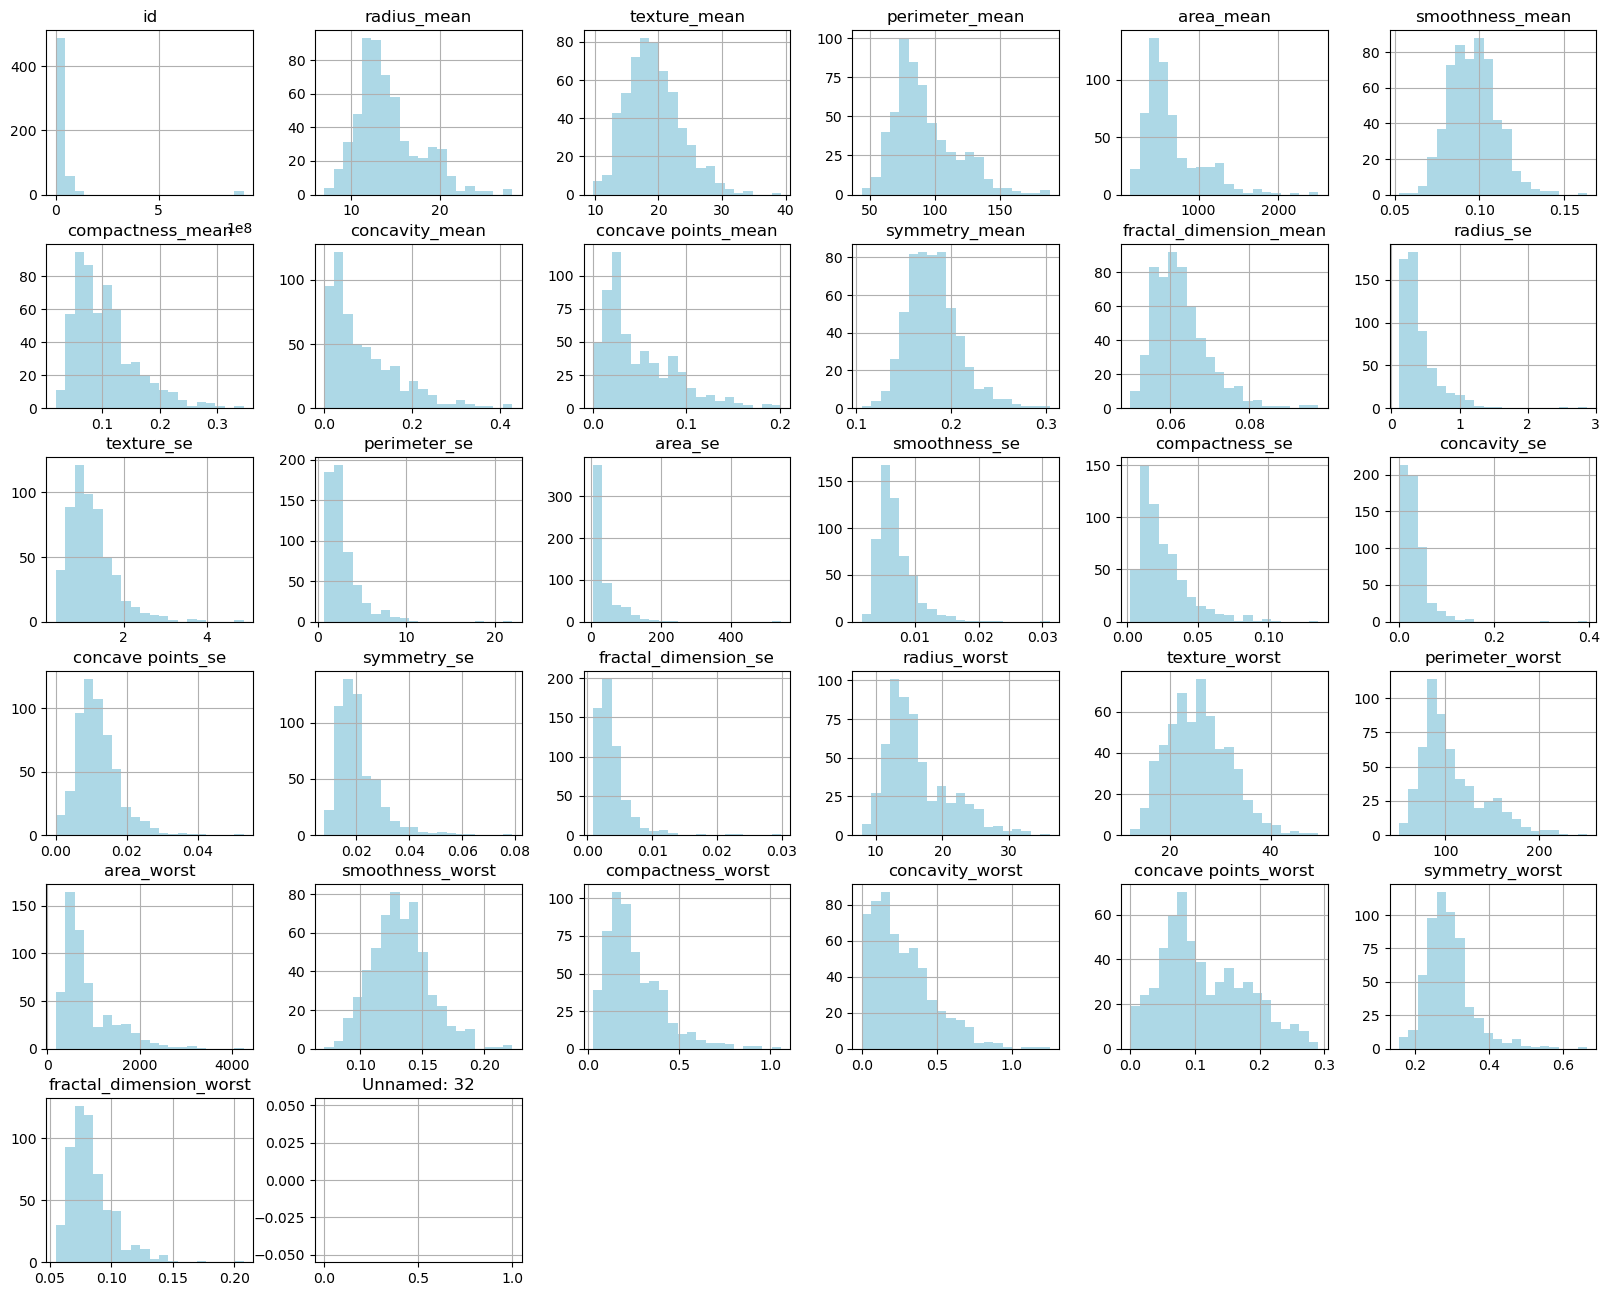

In [11]:
# Use histograms of each variable to visualise the distribution of each attribute.
df.hist(bins=20,figsize=(20, 16), color = 'lightblue')
plt.show()


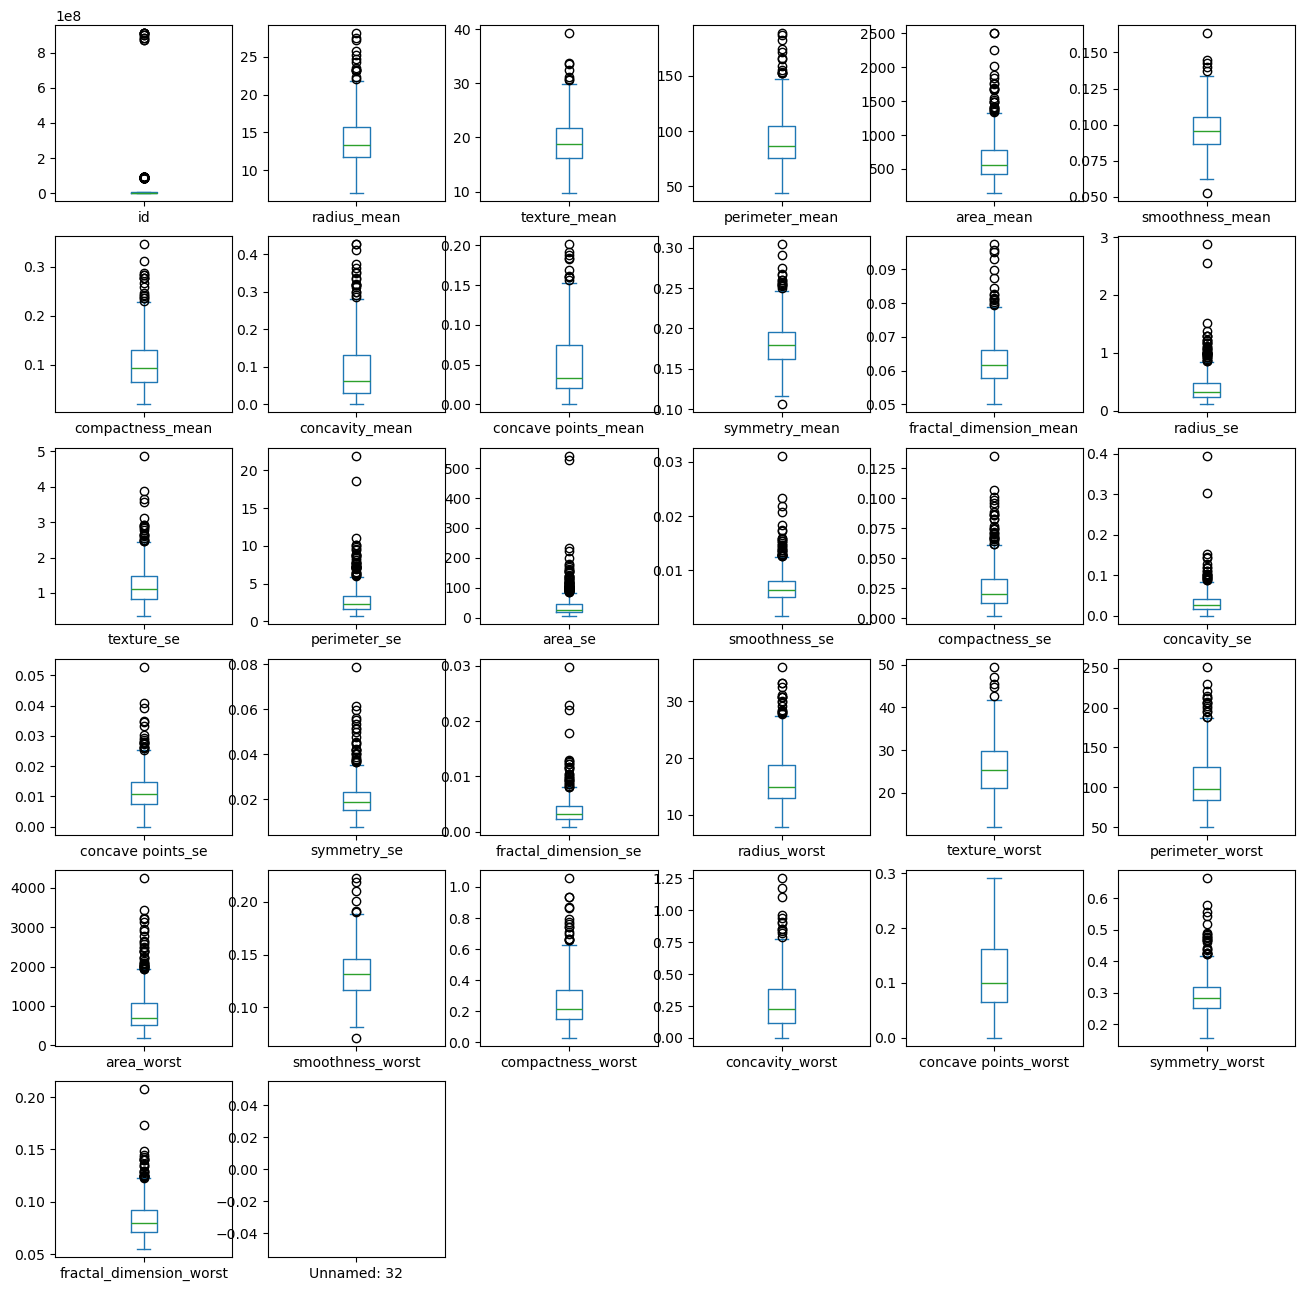

In [12]:
# Use box plots of each variable to visualise the distribution of each attribute.
df.plot(kind='box', subplots=True, layout=(6,6), sharex=False, sharey= False, figsize=(16,16))
plt.show()


##### Check the correlation between varibles

In [13]:
corr_matrix = df.select_dtypes(include='number').corr()
corr_matrix.round(2) 


,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
id,1.00,0.07,0.10,0.07,0.10,-0.01,0.00,0.05,0.04,-0.02,-0.05,0.14,-0.01,0.14,0.18,0.10,0.03,0.06,0.08,-0.02,0.03,0.08,0.06,0.08,0.11,0.01,-0.00,0.02,0.04,-0.04,-0.03,NaN
radius_mean,0.07,1.00,0.32,1.00,0.99,0.17,0.51,0.68,0.82,0.15,-0.31,0.68,-0.10,0.67,0.74,-0.22,0.21,0.19,0.38,-0.10,-0.04,0.97,0.30,0.97,0.94,0.12,0.41,0.53,0.74,0.16,0.01,NaN
texture_mean,0.10,0.32,1.00,0.33,0.32,-0.02,0.24,0.30,0.29,0.07,-0.08,0.28,0.39,0.28,0.26,0.01,0.19,0.14,0.16,0.01,0.05,0.35,0.91,0.36,0.34,0.08,0.28,0.30,0.30,0.11,0.12,NaN
perimeter_mean,0.07,1.00,0.33,1.00,0.99,0.21,0.56,0.72,0.85,0.18,-0.26,0.69,-0.09,0.69,0.74,-0.20,0.25,0.23,0.41,-0.08,-0.01,0.97,0.30,0.97,0.94,0.15,0.46,0.56,0.77,0.19,0.05,NaN
area_mean,0.10,0.99,0.32,0.99,1.00,0.18,0.50,0.69,0.82,0.15,-0.28,0.73,-0.07,0.73,0.80,-0.17,0.21,0.21,0.37,-0.07,-0.02,0.96,0.29,0.96,0.96,0.12,0.39,0.51,0.72,0.14,0.00,NaN
smoothness_mean,-0.01,0.17,-0.02,0.21,0.18,1.00,0.66,0.52,0.55,0.56,0.58,0.30,0.07,0.30,0.25,0.33,0.32,0.25,0.38,0.20,0.28,0.21,0.04,0.24,0.21,0.81,0.47,0.43,0.50,0.39,0.50,NaN
compactness_mean,0.00,0.51,0.24,0.56,0.50,0.66,1.00,0.88,0.83,0.60,0.57,0.50,0.05,0.55,0.46,0.14,0.74,0.57,0.64,0.23,0.51,0.54,0.25,0.59,0.51,0.57,0.87,0.82,0.82,0.51,0.69,NaN
concavity_mean,0.05,0.68,0.30,0.72,0.69,0.52,0.88,1.00,0.92,0.50,0.34,0.63,0.08,0.66,0.62,0.10,0.67,0.69,0.68,0.18,0.45,0.69,0.30,0.73,0.68,0.45,0.75,0.88,0.86,0.41,0.51,NaN
concave points_mean,0.04,0.82,0.29,0.85,0.82,0.55,0.83,0.92,1.00,0.46,0.17,0.70,0.02,0.71,0.69,0.03,0.49,0.44,0.62,0.10,0.26,0.83,0.29,0.86,0.81,0.45,0.67,0.75,0.91,0.38,0.37,NaN
symmetry_mean,-0.02,0.15,0.07,0.18,0.15,0.56,0.60,0.50,0.46,1.00,0.48,0.30,0.13,0.31,0.22,0.19,0.42,0.34,0.39,0.45,0.33,0.19,0.09,0.22,0.18,0.43,0.47,0.43,0.43,0.70,0.44,NaN


##### Plot the correlation Heatmap

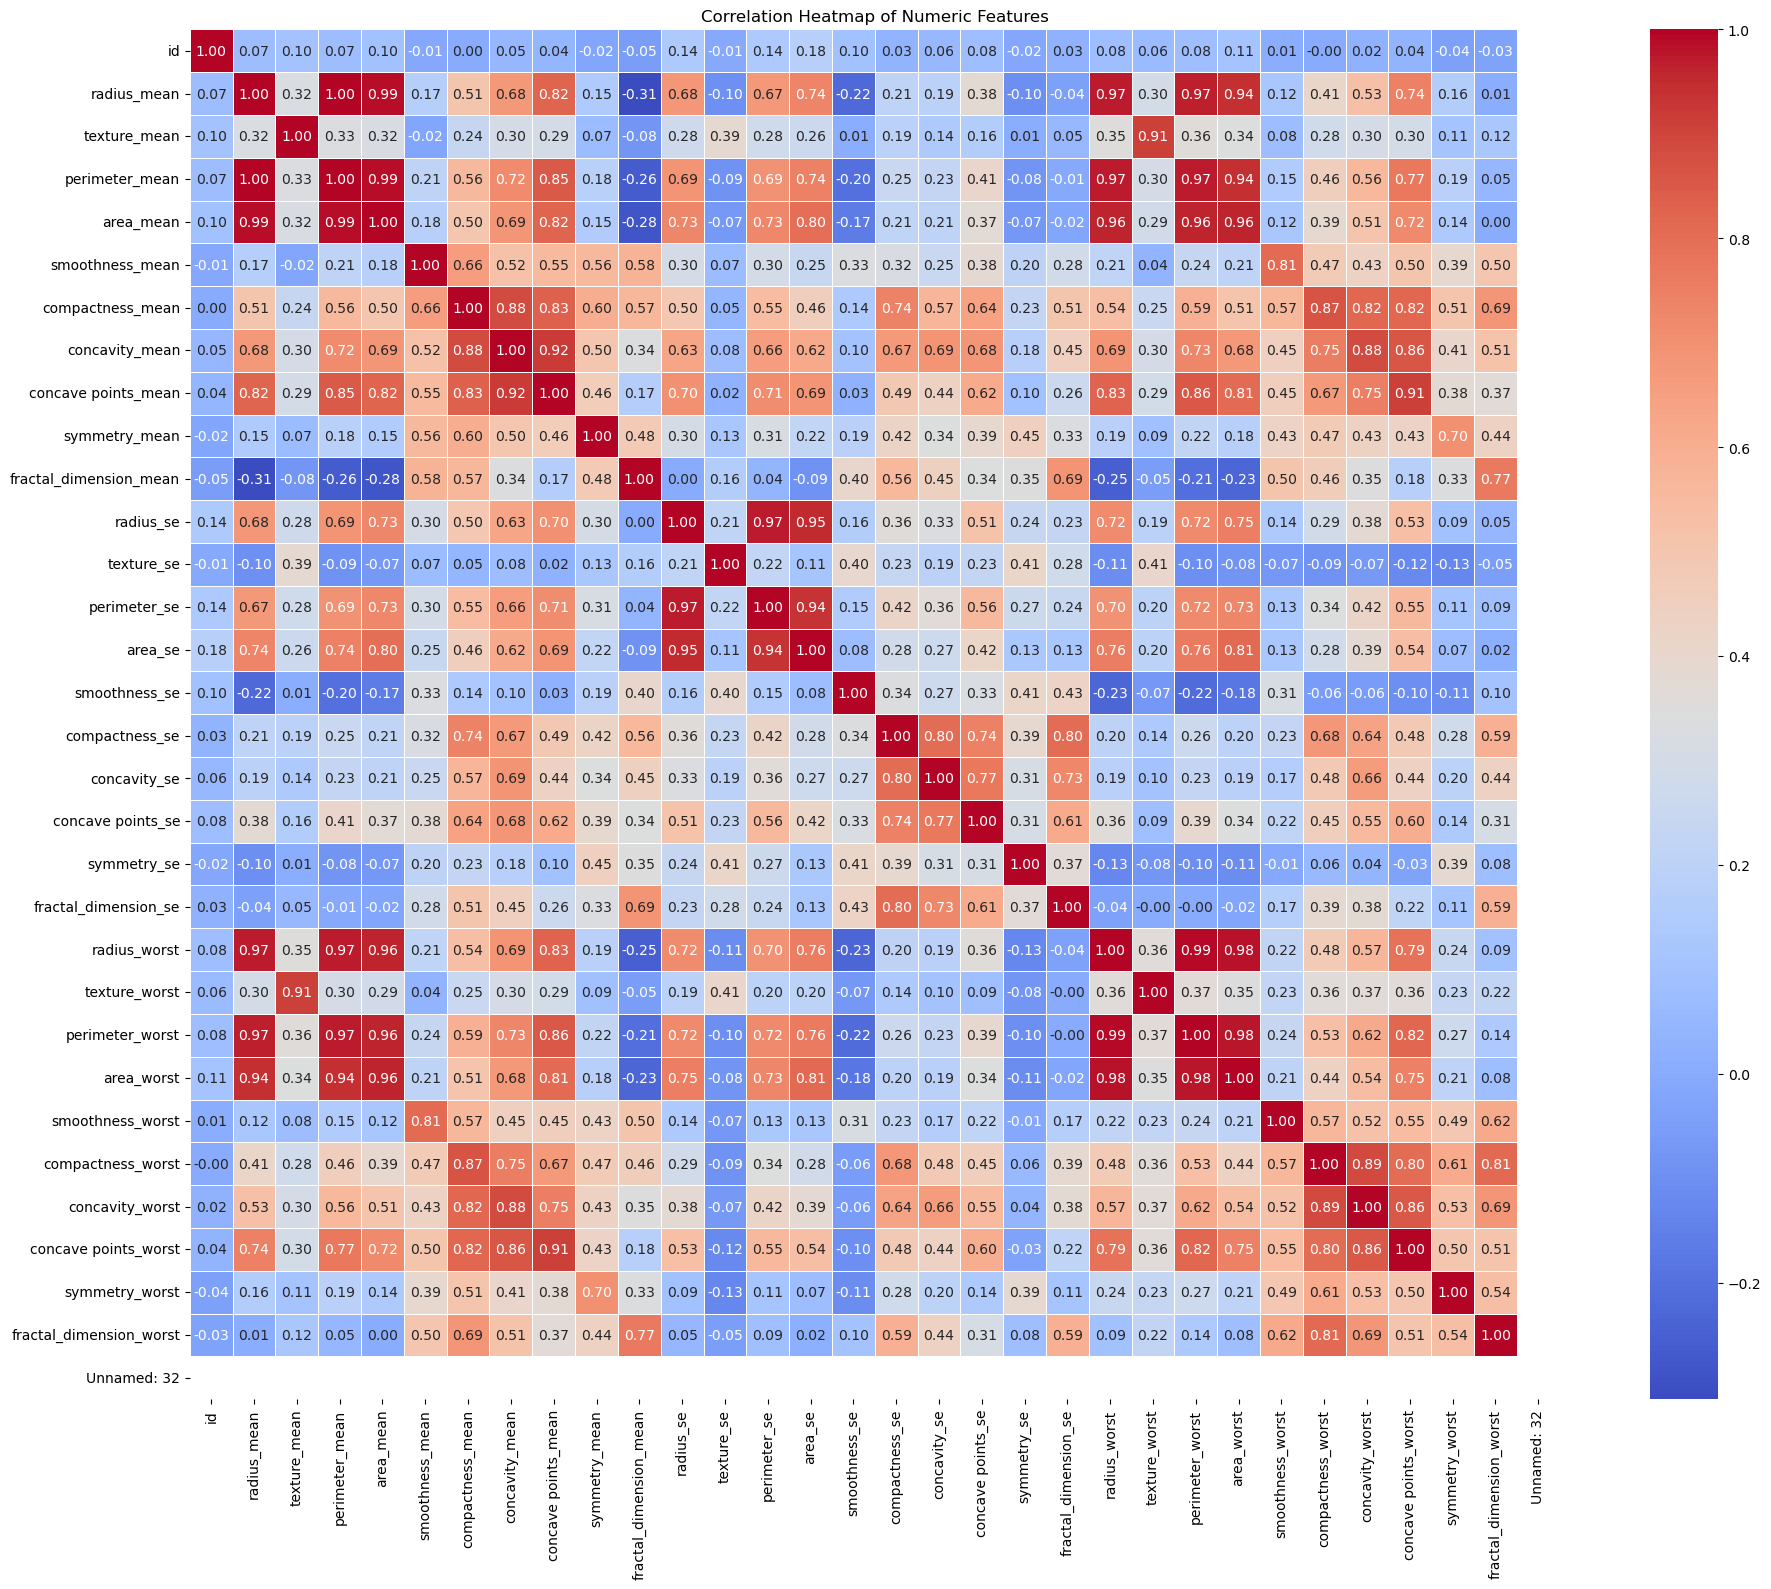

In [14]:
plt.figure(figsize=(20, 16))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True, linewidths=0.5)
plt.title("Correlation Heatmap of Numeric Features")
plt.tight_layout()
plt.show()


### Data preparation

The ID column and the unnamed column containing missing values across all 569 records were excluded from the dataset before analysis.

In [15]:
df=df.copy()
df= df.drop(['id', 'Unnamed: 32'], axis=1)
df.head(5)

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.00,0.12,0.28,0.30,0.15,0.24,0.08,1.09,0.91,8.59,153.40,0.01,0.05,0.05,0.02,0.03,0.01,25.38,17.33,184.60,2019.00,0.16,0.67,0.71,0.27,0.46,0.12
1,M,20.57,17.77,132.90,1326.00,0.08,0.08,0.09,0.07,0.18,0.06,0.54,0.73,3.40,74.08,0.01,0.01,0.02,0.01,0.01,0.00,24.99,23.41,158.80,1956.00,0.12,0.19,0.24,0.19,0.28,0.09
2,M,19.69,21.25,130.00,1203.00,0.11,0.16,0.20,0.13,0.21,0.06,0.75,0.79,4.58,94.03,0.01,0.04,0.04,0.02,0.02,0.00,23.57,25.53,152.50,1709.00,0.14,0.42,0.45,0.24,0.36,0.09
3,M,11.42,20.38,77.58,386.10,0.14,0.28,0.24,0.11,0.26,0.10,0.50,1.16,3.44,27.23,0.01,0.07,0.06,0.02,0.06,0.01,14.91,26.50,98.87,567.70,0.21,0.87,0.69,0.26,0.66,0.17
4,M,20.29,14.34,135.10,1297.00,0.10,0.13,0.20,0.10,0.18,0.06,0.76,0.78,5.44,94.44,0.01,0.02,0.06,0.02,0.02,0.01,22.54,16.67,152.20,1575.00,0.14,0.20,0.40,0.16,0.24,0.08


#### Encode the target variable, "diagnosis". 

In [16]:
# Check the class distribution of the diagnosis
print(df['diagnosis'].value_counts())

diagnosis
B    357
M    212
Name: count, dtype: int64


In [17]:
df=df.copy()

In [18]:
# Encode, M (malignant) -> 1 and  B (benign) -> 0
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})

# Check if encoding worked
df['diagnosis'].value_counts()


diagnosis
0    357
1    212
Name: count, dtype: int64

In [19]:
df.head(10)

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.99,10.38,122.80,1001.00,0.12,0.28,0.30,0.15,0.24,0.08,1.09,0.91,8.59,153.40,0.01,0.05,0.05,0.02,0.03,0.01,25.38,17.33,184.60,2019.00,0.16,0.67,0.71,0.27,0.46,0.12
1,1,20.57,17.77,132.90,1326.00,0.08,0.08,0.09,0.07,0.18,0.06,0.54,0.73,3.40,74.08,0.01,0.01,0.02,0.01,0.01,0.00,24.99,23.41,158.80,1956.00,0.12,0.19,0.24,0.19,0.28,0.09
2,1,19.69,21.25,130.00,1203.00,0.11,0.16,0.20,0.13,0.21,0.06,0.75,0.79,4.58,94.03,0.01,0.04,0.04,0.02,0.02,0.00,23.57,25.53,152.50,1709.00,0.14,0.42,0.45,0.24,0.36,0.09
3,1,11.42,20.38,77.58,386.10,0.14,0.28,0.24,0.11,0.26,0.10,0.50,1.16,3.44,27.23,0.01,0.07,0.06,0.02,0.06,0.01,14.91,26.50,98.87,567.70,0.21,0.87,0.69,0.26,0.66,0.17
4,1,20.29,14.34,135.10,1297.00,0.10,0.13,0.20,0.10,0.18,0.06,0.76,0.78,5.44,94.44,0.01,0.02,0.06,0.02,0.02,0.01,22.54,16.67,152.20,1575.00,0.14,0.20,0.40,0.16,0.24,0.08
5,1,12.45,15.70,82.57,477.10,0.13,0.17,0.16,0.08,0.21,0.08,0.33,0.89,2.22,27.19,0.01,0.03,0.04,0.01,0.02,0.01,15.47,23.75,103.40,741.60,0.18,0.52,0.54,0.17,0.40,0.12
6,1,18.25,19.98,119.60,1040.00,0.09,0.11,0.11,0.07,0.18,0.06,0.45,0.77,3.18,53.91,0.00,0.01,0.02,0.01,0.01,0.00,22.88,27.66,153.20,1606.00,0.14,0.26,0.38,0.19,0.31,0.08
7,1,13.71,20.83,90.20,577.90,0.12,0.16,0.09,0.06,0.22,0.07,0.58,1.38,3.86,50.96,0.01,0.03,0.02,0.01,0.01,0.01,17.06,28.14,110.60,897.00,0.17,0.37,0.27,0.16,0.32,0.12
8,1,13.00,21.82,87.50,519.80,0.13,0.19,0.19,0.09,0.23,0.07,0.31,1.00,2.41,24.32,0.01,0.04,0.04,0.01,0.02,0.00,15.49,30.73,106.20,739.30,0.17,0.54,0.54,0.21,0.44,0.11
9,1,12.46,24.04,83.97,475.90,0.12,0.24,0.23,0.09,0.20,0.08,0.30,1.60,2.04,23.94,0.01,0.07,0.08,0.01,0.02,0.01,15.09,40.68,97.65,711.40,0.19,1.06,1.10,0.22,0.44,0.21


#### Most of the classification models are sensitive to skewness of the varibles. 

#### Before model development, separate the independent and target variables, and then standardize the numerical features to have a mean of 0 and a standard deviation of 1.

In [20]:
df1= df.copy()

In [21]:
from sklearn.preprocessing import StandardScaler

# Separate features (X) and target (y)
X = df.drop('diagnosis', axis=1)
y = df['diagnosis']

# Initialize the scaler
scaler = StandardScaler()

# Fit and transform the features
X_scaled = scaler.fit_transform(X)

# Convert back to DataFrame (optional)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

# Check the result
X_scaled.head()


,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1.10,-2.07,1.27,0.98,1.57,3.28,2.65,2.53,2.22,2.26,2.49,-0.57,2.83,2.49,-0.21,1.32,0.72,0.66,1.15,0.91,1.89,-1.36,2.30,2.00,1.31,2.62,2.11,2.30,2.75,1.94
1,1.83,-0.35,1.69,1.91,-0.83,-0.49,-0.02,0.55,0.00,-0.87,0.50,-0.88,0.26,0.74,-0.61,-0.69,-0.44,0.26,-0.81,-0.10,1.81,-0.37,1.54,1.89,-0.38,-0.43,-0.15,1.09,-0.24,0.28
2,1.58,0.46,1.57,1.56,0.94,1.05,1.36,2.04,0.94,-0.40,1.23,-0.78,0.85,1.18,-0.30,0.81,0.21,1.42,0.24,0.29,1.51,-0.02,1.35,1.46,0.53,1.08,0.85,1.96,1.15,0.20
3,-0.77,0.25,-0.59,-0.76,3.28,3.40,1.92,1.45,2.87,4.91,0.33,-0.11,0.29,-0.29,0.69,2.74,0.82,1.12,4.73,2.05,-0.28,0.13,-0.25,-0.55,3.39,3.89,1.99,2.18,6.05,4.94
4,1.75,-1.15,1.78,1.83,0.28,0.54,1.37,1.43,-0.01,-0.56,1.27,-0.79,1.27,1.19,1.48,-0.05,0.83,1.14,-0.36,0.50,1.30,-1.47,1.34,1.22,0.22,-0.31,0.61,0.73,-0.87,-0.40


#### I am going to use Logistic Regression and Decision Tree/Random Forest models. 

In [22]:
# Split the data into training and testing sets.
# 70% for training and 30% for testing
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

#### Train Models

In [23]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

# Logistic Regression
logR_model = LogisticRegression(max_iter=1000)
logR_model.fit(X_train, y_train)
y_pred_logR = logR_model.predict(X_test)

# Decision Tree
tree_model = DecisionTreeClassifier(random_state=42)
tree_model.fit(X_train, y_train)
y_pred_tree = tree_model.predict(X_test)


#### Evaluate models

In [24]:
# from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, mean_absolute_error
from sklearn.metrics import classification_report, confusion_matrix

# Evaluation function
def evaluate_model(y_true, y_pred, model_name):
    print(f"\n{model_name} Results:")
    print(confusion_matrix(y_true, y_pred))
    print(classification_report(y_true, y_pred))

# Evaluate each model
evaluate_model(y_test, y_pred_logR, "Logistic Regression")
evaluate_model(y_test, y_pred_tree, "Decision Tree")



Logistic Regression Results:
[[106   2]
 [  1  62]]
              precision    recall  f1-score   support

           0       0.99      0.98      0.99       108
           1       0.97      0.98      0.98        63

    accuracy                           0.98       171
   macro avg       0.98      0.98      0.98       171
weighted avg       0.98      0.98      0.98       171


Decision Tree Results:
[[101   7]
 [  3  60]]
              precision    recall  f1-score   support

           0       0.97      0.94      0.95       108
           1       0.90      0.95      0.92        63

    accuracy                           0.94       171
   macro avg       0.93      0.94      0.94       171
weighted avg       0.94      0.94      0.94       171



In [25]:
# Create a DataFrame comparing actual vs predicted values usin Logistic Regression model
resultsLR = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred_logR
})

# Print the first few rows
print(resultsLR.head(20))


    Actual  Predicted
0        0          0
1        1          1
2        1          1
3        0          0
4        0          0
5        1          1
6        1          1
7        1          1
8        0          0
9        0          0
10       0          0
11       1          1
12       0          0
13       1          1
14       0          0
15       1          1
16       0          0
17       0          0
18       0          0
19       1          1


#### The Logistic Regresssion model is performing well for identiying cancer types. 

#### I am going to try how dimentional reduction affects model performance by applying PCA(Principle Componet Anlysis)

1. Apply Principal Component Analysis (PCA) to reduce the dimensionality of the dataset.

2. Retain enough components to explain approximately 95% of the total variance.

3. Re-train a Logistic Regression or Random Forest model using the PCA-transformed data.

4. Compare model performance before and after applying PCA to evaluate the impact of dimensionality reduction.

In [26]:
from sklearn.decomposition import PCA

# Apply PCA to explain 95% of the variance
pca = PCA(n_components=0.95)
X_pca = pca.fit_transform(X_scaled)

print(f"Original feature count: {X.shape[1]}")
print(f"Reduced feature count after PCA: {X_pca.shape[1]}")


Original feature count: 30
Reduced feature count after PCA: 10


##### Visualising PCA Components (2D Scatter Plot)

To better understand how PCA separates the two classes, we can visualise the first two principal components.
Each point represents one observation, colored by its diagnosis (Benign = 0, Malignant = 1).

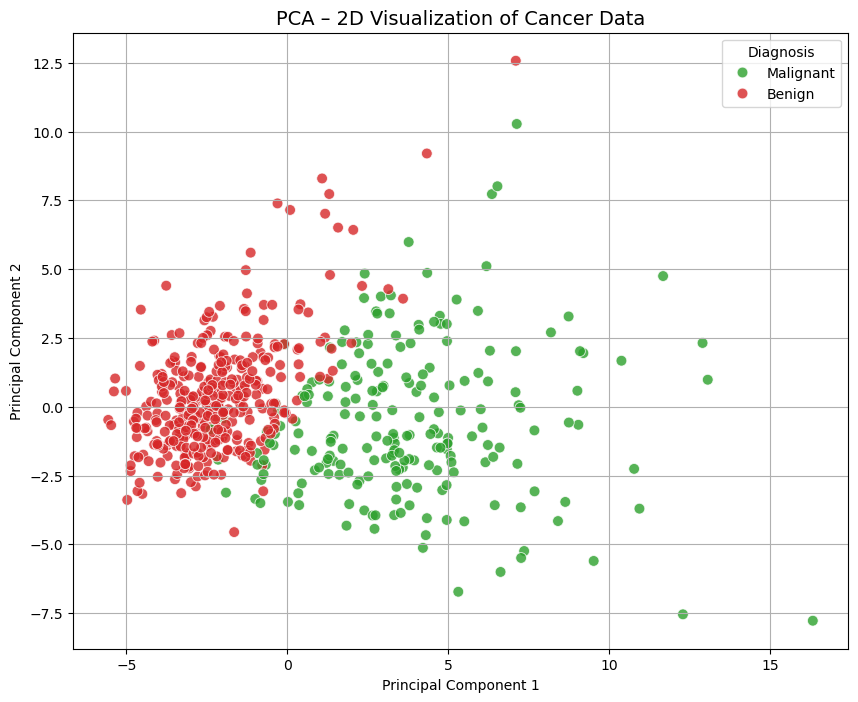

In [27]:
# Apply PCA (2 components for visualisation)
pca_vis = PCA(n_components=2)
X_pca_vis = pca_vis.fit_transform(X_scaled)

# Create a DataFrame for plotting
pca_df = pd.DataFrame(data=X_pca_vis, columns=['PC1', 'PC2'])
pca_df['Diagnosis'] = y.replace({0: 'Benign', 1: 'Malignant'})

# Plot
plt.figure(figsize=(10,8))
sns.scatterplot(
    data=pca_df, 
    x='PC1', 
    y='PC2', 
    hue='Diagnosis', 
    palette=['#2ca02c','#d62728'], 
    s=60, alpha=0.8
)
plt.title('PCA – 2D Visualization of Cancer Data', fontsize=14)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Diagnosis')
plt.grid(True)
plt.show()


* The scatter plot shows that benign and malignant samples form distinct clusters along the first two principal components.

* This indicates that PCA successfully captured the most important variance in the data that separates the two cancer types.

* These two components alone already provide strong class separation, explaining why your PCA-based models achieved high accuracy.

#### PCA Loadings
##### Check how much original features contributes to each the Principal Component (PC).

* Loadings are the correlation coefficients between the original variables and the principal components.

* Each loading shows how strongly a feature influences a particular PC.

* High absolute loadings (positive or negative) mean that feature is important for that component.


In [28]:
# Apply PCA (retain enough components to explain ~95% variance)
pca = PCA(n_components=0.95)
pca.fit(X_scaled)

# Create a DataFrame for PCA loadings
loadings = pd.DataFrame(
    pca.components_.T,  # transpose so features are rows, PCs are columns
    columns=[f'PC{i+1}' for i in range(pca.n_components_)],
    index=X.columns
)

# Display top loadings
print(loadings.head(5))

                                 PC1                  PC2  \
radius_mean                     0.22                -0.23   
texture_mean                    0.10                -0.06   
perimeter_mean                  0.23                -0.22   
area_mean                       0.22                -0.23   
smoothness_mean                 0.14                 0.19   

                                 PC3                  PC4  \
radius_mean                    -0.01                -0.04   
texture_mean                    0.06                 0.60   
perimeter_mean                 -0.01                -0.04   
area_mean                       0.03                -0.05   
smoothness_mean                -0.10                -0.16   

                                 PC5                  PC6  \
radius_mean                    -0.04                 0.02   
texture_mean                    0.05                -0.03   
perimeter_mean                 -0.04                 0.02   
area_mean             

##### Visualise PCA loading using heatmap

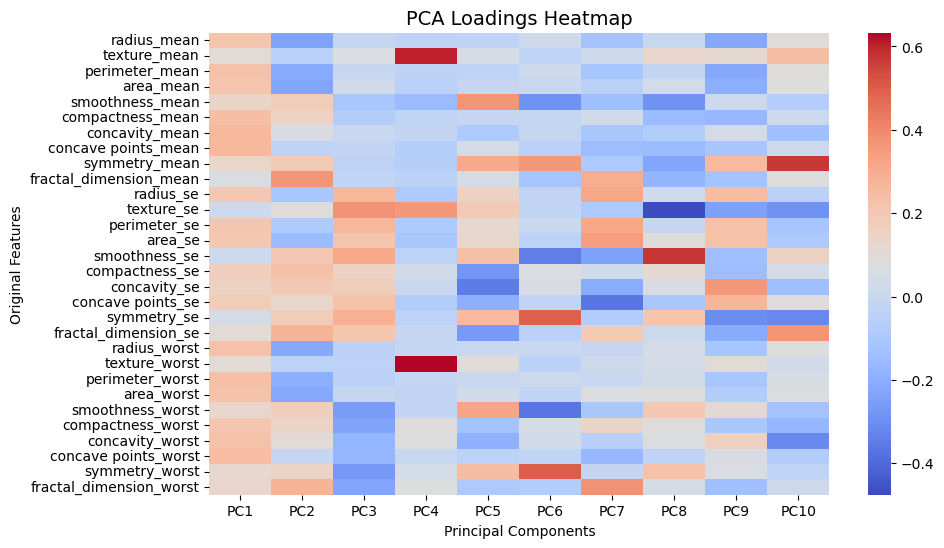

In [29]:
plt.figure(figsize=(10,6))
sns.heatmap(loadings, cmap='coolwarm', annot=False)
plt.title('PCA Loadings Heatmap', fontsize=14)
plt.xlabel('Principal Components')
plt.ylabel('Original Features')
plt.show()

PCA scores: How each original data point is represented in the new, lower-dimensional principal component space.

##### Train logistic regression on PCA features and evalute the model

In [30]:
# Split the PCA-transformed data
X_train, X_test, y_train, y_test = train_test_split(X_pca, y, test_size=0.3, random_state=42)

# Train the model
model_pca_lr = LogisticRegression(random_state=42)
model_pca_lr.fit(X_train, y_train)

# Predict
y_pred = model_pca_lr.predict(X_test)

# Evaluate
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Confusion Matrix:
 [[106   2]
 [  1  62]]

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.98      0.99       108
           1       0.97      0.98      0.98        63

    accuracy                           0.98       171
   macro avg       0.98      0.98      0.98       171
weighted avg       0.98      0.98      0.98       171



##### Try Randaom Forest with PCA data and evalute the model

In [31]:
from sklearn.ensemble import RandomForestClassifier

model_pca_rf = RandomForestClassifier(random_state=42)
model_pca_rf.fit(X_train, y_train)

y_pred_rf = model_pca_rf.predict(X_test)

print("Random Forest Results with PCA:\n")
print(confusion_matrix(y_test, y_pred_rf))
print("\n", classification_report(y_test, y_pred_rf))


Random Forest Results with PCA:

[[104   4]
 [  3  60]]

               precision    recall  f1-score   support

           0       0.97      0.96      0.97       108
           1       0.94      0.95      0.94        63

    accuracy                           0.96       171
   macro avg       0.95      0.96      0.96       171
weighted avg       0.96      0.96      0.96       171



#### **Conclusion**

A predictive model was developed to classify tumours as benign or malignant using the Breast Cancer dataset. Logistic Regression and Random Forest achieved high accuracy, with Logistic Regression reaching 98% after applying PCA. Dimensionality reduction improved model efficiency and highlighted the most important features, making the model both accurate and interpretable.


